In [1]:
import requests
!pip install beautifulsoup4 pandas
from bs4 import BeautifulSoup
import pandas as pd
!pip install openpyxl
import pandas as pd

In [2]:
base_url = "https://www.airlinequality.com/airline-reviews/united-airlines"
pages = 55
page_size = 100

reviews = []
type_of_traveller = []
route = []
recommendation = []
ratings = []
cabin_staff_service = []
seat_comfort = []
food_beverages = []
ground_service = []
value_money = []
wifi_connectivity = []
inflight_entertainment = []

# for i in range(1, pages + 1):
for i in range(1, pages + 1):

    print(f"Scraping page {i}")

    # Create URL to collect links from paginated data
    url = f"{base_url}/page/{i}/?sortby=post_date%3ADesc&pagesize={page_size}"

    # Collect HTML data from this page
    response = requests.get(url)

    # Parse content
    content = response.content
    parsed_content = BeautifulSoup(content, 'html.parser')
    
    # Extract reviews
    for para in parsed_content.find_all("div", {"class": "text_content"}):
        reviews.append(para.get_text())
    
    # Extract type_of_traveller - find all tds containing the text, then get the next sibling
    for td in parsed_content.find_all("td", string="Type Of Traveller"):
        next_td = td.find_next("td")
        if next_td:
            type_of_traveller.append(next_td.get_text(strip=True))
    
    # Extract route - find all tds containing the text, then get the next sibling
    for td in parsed_content.find_all("td", string="Route"):
        next_td = td.find_next("td")
        if next_td:
            route.append(next_td.get_text(strip=True))
    
    # Extract recommendation - find all tds containing the text, then get the next sibling
    for td in parsed_content.find_all("td", string="Recommended"):
        next_td = td.find_next("td")
        if next_td:
            recommendation.append(next_td.get_text(strip=True))
    
    # Extract overall ratings
    for review_article in parsed_content.find_all("article", {"itemprop": "review"}):
        rating_span = review_article.find("span", {"itemprop": "ratingValue"})
        if rating_span:
            ratings.append(rating_span.get_text(strip=True))
        
        # Extract detailed ratings for each category
        rating_labels = {
            "Cabin Staff Service": cabin_staff_service,
            "Seat Comfort": seat_comfort,
            "Food & Beverages": food_beverages,
            "Ground Service": ground_service,
            "Value For Money": value_money,
            "Wifi & Connectivity": wifi_connectivity,
            "Inflight Entertainment": inflight_entertainment
        }
        
        for label, list_var in rating_labels.items():
            td_label = review_article.find("td", string=label)
            if td_label:
                next_td = td_label.find_next("td")
                if next_td:
                    filled_stars = next_td.find_all("span", {"class": "fill"})
                    list_var.append(str(len(filled_stars)))
            else:
                # If not found, append empty string
                list_var.append("")

    print(f"   ---> {len(reviews)} total reviews")

Scraping page 1
   ---> 100 total reviews
Scraping page 2
   ---> 200 total reviews
Scraping page 3
   ---> 300 total reviews
Scraping page 4
   ---> 400 total reviews
Scraping page 5
   ---> 500 total reviews
Scraping page 6
   ---> 600 total reviews
Scraping page 7
   ---> 700 total reviews
Scraping page 8
   ---> 800 total reviews
Scraping page 9
   ---> 900 total reviews
Scraping page 10
   ---> 1000 total reviews
Scraping page 11
   ---> 1100 total reviews
Scraping page 12
   ---> 1200 total reviews
Scraping page 13
   ---> 1300 total reviews
Scraping page 14
   ---> 1400 total reviews
Scraping page 15
   ---> 1500 total reviews
Scraping page 16
   ---> 1600 total reviews
Scraping page 17
   ---> 1700 total reviews
Scraping page 18
   ---> 1800 total reviews
Scraping page 19
   ---> 1900 total reviews
Scraping page 20
   ---> 2000 total reviews
Scraping page 21
   ---> 2100 total reviews
Scraping page 22
   ---> 2200 total reviews
Scraping page 23
   ---> 2300 total reviews
Scrapi

In [3]:
# Check the length of each list to debug
print(f"reviews: {len(reviews)}")
print(f"type_of_traveller: {len(type_of_traveller)}")
print(f"route: {len(route)}")
print(f"recommendation: {len(recommendation)}")
print(f"ratings: {len(ratings)}")
print(f"cabin_staff_service: {len(cabin_staff_service)}")
print(f"seat_comfort: {len(seat_comfort)}")
print(f"food_beverages: {len(food_beverages)}")
print(f"ground_service: {len(ground_service)}")
print(f"value_money: {len(value_money)}")
print(f"wifi_connectivity: {len(wifi_connectivity)}")
print(f"inflight_entertainment: {len(inflight_entertainment)}")

# Print a sample of what was scraped
if reviews:
    print(f"\nFirst review sample:\n{reviews[0][:200]}")

reviews: 5136
type_of_traveller: 4407
route: 4381
recommendation: 5136
ratings: 5135
cabin_staff_service: 5136
seat_comfort: 5136
food_beverages: 5136
ground_service: 5136
value_money: 5136
wifi_connectivity: 5136
inflight_entertainment: 5136

First review sample:
Not Verified |  Domestic flying in the US is, in general, the pits. It is a reminder of just how basic the air transport product has become. That said, our flight from San Francisco to Boston on Unite


In [4]:
# Debug: Extract filled stars for each rating category
url = "https://www.airlinequality.com/airline-reviews/qantas-airways/page/1/?sortby=post_date%3ADesc&pagesize=5"
response = requests.get(url)
parsed_content = BeautifulSoup(response.content, 'html.parser')

review_article = parsed_content.find("article", {"itemprop": "review"})
rating_labels = ["Cabin Staff Service", "Seat Comfort", "Food & Beverages", 
                 "Ground Service", "Value For Money", "Wifi & Connectivity", 
                 "Inflight Entertainment"]

if review_article:
    for label in rating_labels:
        td_label = review_article.find("td", string=label)
        if td_label:
            # Get the next td
            next_td = td_label.find_next("td")
            if next_td:
                # Count filled stars in this td
                filled_stars = next_td.find_all("span", {"class": "fill"})
                rating_value = len(filled_stars)
                print(f"{label}: {rating_value} stars")

Cabin Staff Service: 4 stars
Seat Comfort: 3 stars
Food & Beverages: 3 stars
Ground Service: 3 stars
Value For Money: 3 stars


In [5]:
# Trim all lists to match the minimum length
all_lists = [reviews, type_of_traveller, route, recommendation, ratings, cabin_staff_service, 
             seat_comfort, food_beverages, ground_service, value_money, wifi_connectivity, 
             inflight_entertainment]
min_length = min(len(lst) for lst in all_lists)

reviews = reviews[:min_length]
type_of_traveller = type_of_traveller[:min_length]
route = route[:min_length]
recommendation = recommendation[:min_length]
ratings = ratings[:min_length]
cabin_staff_service = cabin_staff_service[:min_length]
seat_comfort = seat_comfort[:min_length]
food_beverages = food_beverages[:min_length]
ground_service = ground_service[:min_length]
value_money = value_money[:min_length]
wifi_connectivity = wifi_connectivity[:min_length]
inflight_entertainment = inflight_entertainment[:min_length]

df = pd.DataFrame()
df["reviews"] = reviews
df["type_of_traveller"] = type_of_traveller
df["route"] = route
df["recommendation"] = recommendation
df["ratings"] = ratings
df["cabin_staff_service"] = cabin_staff_service
df["seat_comfort"] = seat_comfort
df["food_beverages"] = food_beverages
df["ground_service"] = ground_service
df["value_money"] = value_money
df["wifi_connectivity"] = wifi_connectivity
df["inflight_entertainment"] = inflight_entertainment
df.head(30)

,reviews,type_of_traveller,route,recommendation,ratings,cabin_staff_service,seat_comfort,food_beverages,ground_service,value_money,wifi_connectivity,inflight_entertainment
0,"Not Verified | Domestic flying in the US is, ...",Couple Leisure,San Francisco to Boston,yes,8,5,4,3,5,5,3,3
1,✅ Trip Verified | I recently flew with United...,Business,Denver to Tokyo Narita,no,1,2,3,2,1,2,2,4
2,✅ Trip Verified | I booked a round trip flig...,Solo Leisure,Miami to LaGuardia,no,1,3,3,3,1,1,1,1
3,Not Verified | All in all a pleasant experien...,Couple Leisure,San Francisco to Sydney,yes,9,5,5,4,5,5,,5
4,Not Verified | Despite United’s overweight ba...,Solo Leisure,Denver to San Jose,no,1,3,3,1,1,1,1,1
5,"✅ Trip Verified | In June 2025, I flew with ...",Family Leisure,Los Angeles to Narita,no,1,1,1,3,1,1,,
6,Not Verified | I’ve flown with United Airline...,Business,Phœnix to Boston via Orlando,no,1,1,1,1,1,1,2,1
7,✅ Trip Verified | We traveled with United from...,Couple Leisure,London to Managua via Houston,no,1,4,2,3,1,1,2,3
8,Not Verified | I recently flew on United Airl...,Solo Leisure,Sydney to Houston,no,2,3,2,3,1,3,1,3
9,✅ Trip Verified | DFW-IAH on A320. Seating ...,Couple Leisure,DFW to LAX via IAH,yes,8,4,5,,4,5,3,3


In [6]:

import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/BA_reviews.csv", index=False)

In [7]:
# Convert recommendation column: Yes to 1, No to 0
df["recommendation"] = df["recommendation"].apply(lambda x: 1 if isinstance(x, str) and x.lower() == "yes" else (1 if x == 1 else 0))

# Convert type_of_traveller: Business to 1, other to 0
df["type_of_traveller"] = df["type_of_traveller"].apply(lambda x: 1 if isinstance(x, str) and "business" in x.lower() else (1 if x == 1 else 0))

# Convert to integers
df["recommendation"] = df["recommendation"].astype(int)
df["type_of_traveller"] = df["type_of_traveller"].astype(int)

# Display first 10 rows and data types
print("First 10 rows after conversion:")
print(df.head(10))
print("\nData types:")
print(df.dtypes)

df.head(30)

First 10 rows after conversion:
                                             reviews  type_of_traveller  \
0  Not Verified |  Domestic flying in the US is, ...                  0   
1  ✅ Trip Verified |  I recently flew with United...                  1   
2  ✅ Trip Verified |   I booked a round trip flig...                  0   
3  Not Verified |  All in all a pleasant experien...                  0   
4  Not Verified |  Despite United’s overweight ba...                  0   
5  ✅ Trip Verified |   In June 2025, I flew with ...                  0   
6  Not Verified |  I’ve flown with United Airline...                  1   
7  ✅ Trip Verified | We traveled with United from...                  0   
8  Not Verified |  I recently flew on United Airl...                  0   
9  ✅ Trip Verified |    DFW-IAH on A320. Seating ...                  0   

                           route  recommendation ratings cabin_staff_service  \
0        San Francisco to Boston               1       8      

,reviews,type_of_traveller,route,recommendation,ratings,cabin_staff_service,seat_comfort,food_beverages,ground_service,value_money,wifi_connectivity,inflight_entertainment
0,"Not Verified | Domestic flying in the US is, ...",0,San Francisco to Boston,1,8,5,4,3,5,5,3,3
1,✅ Trip Verified | I recently flew with United...,1,Denver to Tokyo Narita,0,1,2,3,2,1,2,2,4
2,✅ Trip Verified | I booked a round trip flig...,0,Miami to LaGuardia,0,1,3,3,3,1,1,1,1
3,Not Verified | All in all a pleasant experien...,0,San Francisco to Sydney,1,9,5,5,4,5,5,,5
4,Not Verified | Despite United’s overweight ba...,0,Denver to San Jose,0,1,3,3,1,1,1,1,1
5,"✅ Trip Verified | In June 2025, I flew with ...",0,Los Angeles to Narita,0,1,1,1,3,1,1,,
6,Not Verified | I’ve flown with United Airline...,1,Phœnix to Boston via Orlando,0,1,1,1,1,1,1,2,1
7,✅ Trip Verified | We traveled with United from...,0,London to Managua via Houston,0,1,4,2,3,1,1,2,3
8,Not Verified | I recently flew on United Airl...,0,Sydney to Houston,0,2,3,2,3,1,3,1,3
9,✅ Trip Verified | DFW-IAH on A320. Seating ...,0,DFW to LAX via IAH,1,8,4,5,,4,5,3,3


In [8]:

data = df[['type_of_traveller', 'recommendation', 'cabin_staff_service', 'seat_comfort', 'food_beverages', 'ground_service', 'value_money', 'wifi_connectivity',
            'inflight_entertainment']]
data.head()

,type_of_traveller,recommendation,cabin_staff_service,seat_comfort,food_beverages,ground_service,value_money,wifi_connectivity,inflight_entertainment
0,0,1,5,4,3,5,5,3,3
1,1,0,2,3,2,1,2,2,4
2,0,0,3,3,3,1,1,1,1
3,0,1,5,5,4,5,5,,5
4,0,0,3,3,1,1,1,1,1


In [9]:
data = data.replace(['NaN', ''], int(0))

In [10]:
data=data.astype(int)

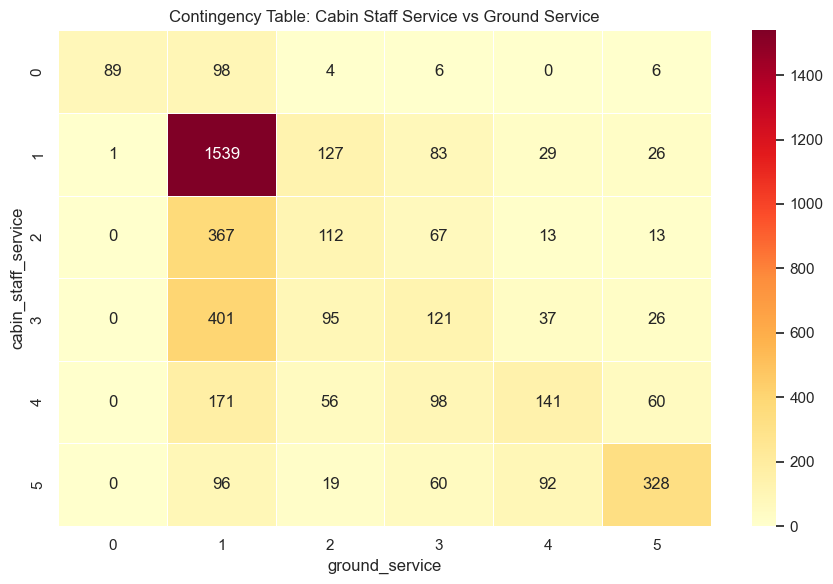

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Create a contingency table (crosstab) of cabin_staff_service vs ground_service
# This counts the frequency of each combination
flights = pd.crosstab(data['cabin_staff_service'], data['ground_service'])

# Draw a heatmap with the numeric values in each cell
f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(flights, annot=True, fmt="d", linewidths=.5, ax=ax, cmap='YlOrRd')
plt.title('Contingency Table: Cabin Staff Service vs Ground Service')
plt.tight_layout()
plt.show()

<Axes: >

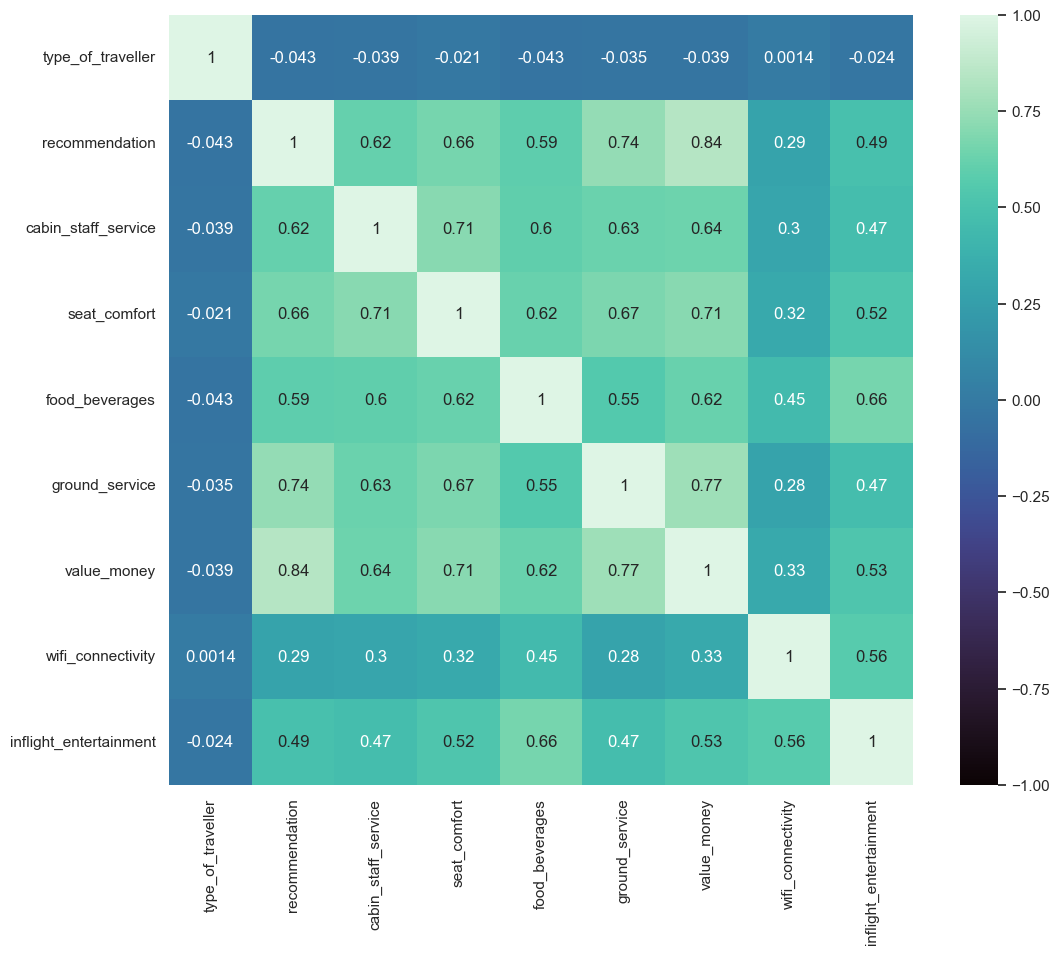

In [13]:
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), annot = True,vmin=-1.0,cmap='mako')

In [14]:
import numpy as np
import pandas as pd
import warnings
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Read the dataset
X = data.copy()

# Replace NaN values with 0
X = X.fillna(0)

# Scale using pandas min-max normalization (avoids sklearn import that triggers scipy._propack error)
X_scaled = (X - X.min()) / (X.max() - X.min())


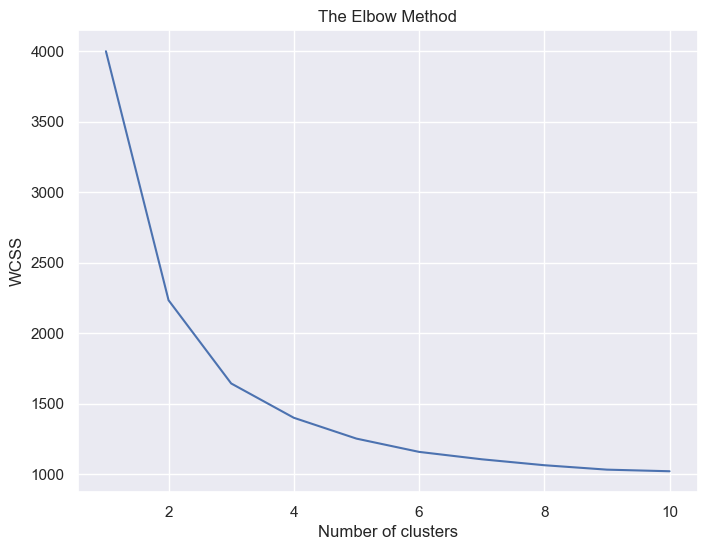

In [15]:
#Manual K-means implementation (avoids sklearn import that triggers scipy._propack error)
import numpy as np

def kmeans_manual(X, n_clusters, max_iter=300, random_state=0):
    """Simple K-means implementation"""
    np.random.seed(random_state)
    n_samples = X.shape[0]
    
    # Initialize cluster centers randomly
    indices = np.random.choice(n_samples, n_clusters, replace=False)
    centers = X[indices].copy()
    
    for iteration in range(max_iter):
        # Assign points to nearest center
        distances = np.sqrt(((X - centers[:, np.newaxis])**2).sum(axis=2))
        labels = np.argmin(distances, axis=0)
        
        # Update centers
        new_centers = np.array([X[labels == k].mean(axis=0) for k in range(n_clusters)])
        
        # Check for convergence
        if np.allclose(centers, new_centers):
            centers = new_centers
            break
        centers = new_centers
    
    # Calculate inertia (sum of squared distances to nearest center)
    distances = np.sqrt(((X - centers[:, np.newaxis])**2).sum(axis=2))
    labels = np.argmin(distances, axis=0)
    inertia = np.sum(np.min(distances, axis=0)**2)
    
    return labels, centers, inertia

# Compute WCSS (Within-Cluster Sum of Squares) for elbow method

wcss = []
X_array = X_scaled.values  # Convert DataFrame to numpy array
for i in range(1, 11):
    labels, centers, inertia = kmeans_manual(X_array, n_clusters=i, random_state=0)
    wcss.append(inertia)

f3, ax = plt.subplots(figsize=(8, 6))
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:

# Use k=7 for final clustering
labels, centers, inertia = kmeans_manual(X_array, n_clusters=7, random_state=0)

In [26]:
# Use the manual K-means results from previous cell (already computed with k=3)
clusterNum = 7
print(f"Cluster assignments (manual K-means with {clusterNum} clusters):")
print(labels)
print(f"\nCluster distribution:")
unique, counts = np.unique(labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"Cluster {cluster_id}: {count} samples")

Cluster assignments (manual K-means with 7 clusters):
[2 1 4 ... 2 4 0]

Cluster distribution:
Cluster 0: 708 samples
Cluster 1: 738 samples
Cluster 2: 467 samples
Cluster 3: 425 samples
Cluster 4: 607 samples
Cluster 5: 300 samples
Cluster 6: 1136 samples


In [45]:
clustered_data = data.copy()
#clustered_data['Cluster'] = cluster_id
clustered_data.head(50)

,type_of_traveller,recommendation,cabin_staff_service,seat_comfort,food_beverages,ground_service,value_money,wifi_connectivity,inflight_entertainment,Cluster
0,0,1,5,4,3,5,5,3,3,2
1,1,0,2,3,2,1,2,2,4,1
2,0,0,3,3,3,1,1,1,1,4
3,0,1,5,5,4,5,5,0,5,2
4,0,0,3,3,1,1,1,1,1,4
5,0,0,1,1,3,1,1,0,0,6
6,1,0,1,1,1,1,1,2,1,1
7,0,0,4,2,3,1,1,2,3,3
8,0,0,3,2,3,1,3,1,3,3
9,0,1,4,5,0,4,5,3,3,2


Cluster Density Maps

Cluster Heatmaps

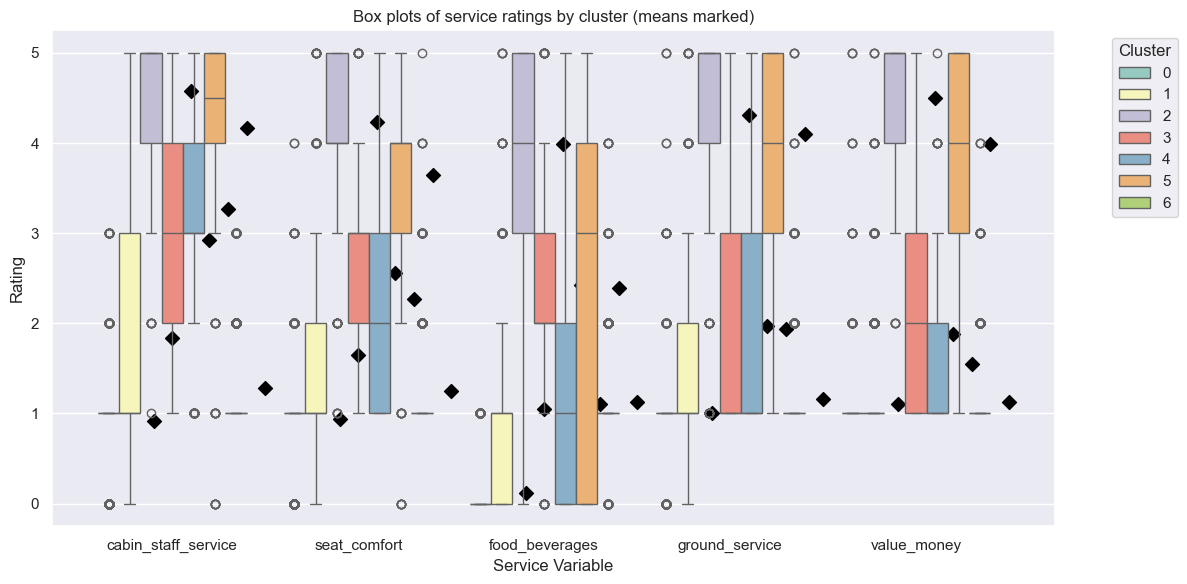

Box plots with averages complete


In [46]:
import seaborn as sns

# Prepare data for boxplots: melt the service variable columns
service_vars = ['cabin_staff_service','seat_comfort','food_beverages','ground_service','value_money']

if 'Cluster' not in data.columns:
    try:
        data['Cluster'] = labels
    except NameError:
        data['Cluster'] = 0

melted = data[['Cluster'] + service_vars].melt(id_vars='Cluster',
                                               value_vars=service_vars,
                                               var_name='Service',
                                               value_name='Rating')

plt.figure(figsize=(12, 6))
sns.boxplot(x='Service', y='Rating', hue='Cluster', data=melted, palette='Set3')

# calculate and plot means
means = melted.groupby(['Cluster','Service'])['Rating'].mean().reset_index()
for _, row in means.iterrows():
    x = service_vars.index(row['Service'])
    plt.scatter(x + (row['Cluster']*0.1 - 0.1), row['Rating'],
                color='black', marker='D', s=50, label='_nolegend_')

plt.title('Box plots of service ratings by cluster (means marked)')
plt.ylabel('Rating')
plt.xlabel('Service Variable')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Box plots with averages complete')

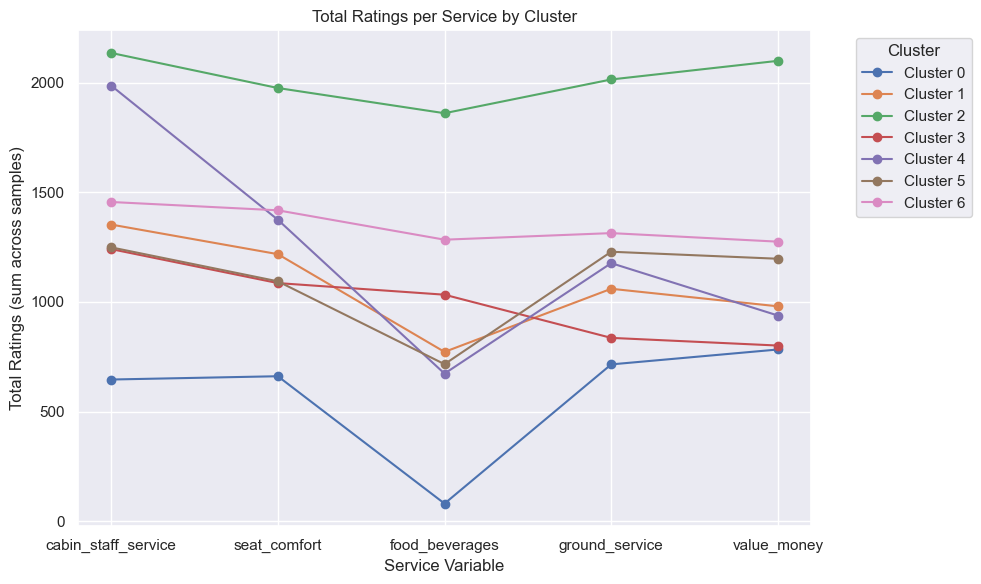

Service totals line graph per cluster complete


In [47]:
import seaborn as sns

# Calculate service variable totals for each cluster
service_vars = ['cabin_staff_service','seat_comfort','food_beverages','ground_service','value_money']

if 'Cluster' not in data.columns:
    try:
        data['Cluster'] = labels
    except NameError:
        data['Cluster'] = 0

# sum ratings per service for each cluster
cluster_service_totals = data.groupby('Cluster')[service_vars].sum()

# plot a line for each cluster across service variables
plt.figure(figsize=(10,6))
for cluster_id, row in cluster_service_totals.iterrows():
    plt.plot(service_vars, row.values, marker='o', label=f'Cluster {cluster_id}')

plt.xlabel('Service Variable')
plt.ylabel('Total Ratings (sum across samples)')
plt.title('Total Ratings per Service by Cluster')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Service totals line graph per cluster complete')

In [ ]:
labels, centers, inertia = kmeans_manual(X_array, n_clusters=5, random_state=0)

In [ ]:
clusterNum = 5
print(f"Cluster assignments (manual K-means with {clusterNum} clusters):")
print(labels)
print(f"\nCluster distribution:")
unique, counts = np.unique(labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"Cluster {cluster_id}: {count} samples")

Cluster assignments (manual K-means with 5 clusters):
[2 1 3 ... 2 3 0]

Cluster distribution:
Cluster 0: 1970 samples
Cluster 1: 741 samples
Cluster 2: 468 samples
Cluster 3: 901 samples
Cluster 4: 301 samples


In [ ]:
clustered_data = data.copy()
#clustered_data['Cluster'] = cluster_id
clustered_data.head(50)

,type_of_traveller,recommendation,cabin_staff_service,seat_comfort,food_beverages,ground_service,value_money,wifi_connectivity,inflight_entertainment,Cluster,TotalRating
0,0,1,5,4,3,5,5,3,3,2,22
1,1,0,2,3,2,1,2,2,4,1,10
2,0,0,3,3,3,1,1,1,1,4,11
3,0,1,5,5,4,5,5,0,5,2,24
4,0,0,3,3,1,1,1,1,1,4,9
5,0,0,1,1,3,1,1,0,0,6,7
6,1,0,1,1,1,1,1,2,1,1,5
7,0,0,4,2,3,1,1,2,3,3,11
8,0,0,3,2,3,1,3,1,3,3,12
9,0,1,4,5,0,4,5,3,3,2,18
